# 4.2 — Reducción de varianza I: antitéticas, control variates, estratificación y LHS

El notebook anterior dejó el diagnóstico: el error de Monte Carlo es $\sigma_Y/\sqrt n$ y el exponente $-1/2$ no se negocia. Lo que sí se puede atacar es la **constante** $\sigma_Y$, y de eso trata este notebook. Las cuatro técnicas clásicas comparten una misma idea — usar estructura conocida del problema para no gastar trayectorias en re-descubrirla — pero difieren en qué estructura explotan: la simetría de la normal (antitéticas), la existencia de un instrumento parecido con precio cerrado (control variates), la posibilidad de forzar la distribución en vez de sortearla (estratificación) y la de hacerlo dimensión por dimensión (LHS).

Dos advertencias de método que este notebook toma en serio, porque son donde uno se engaña:

**La métrica correcta es la eficiencia, no la varianza.** Un estimador con la mitad de varianza pero que cuesta el triple es peor. La comparación honesta es $\text{Var}\times\text{trabajo}$, y por eso las antitéticas se comparan *por evaluación del payoff* y no por par: dos evaluaciones antitéticas cuestan lo mismo que dos independientes.

**Medir la varianza de un estimador no iid exige réplicas.** Con Monte Carlo crudo la varianza muestral de los payoffs estima la varianza del promedio (dividida entre $n$), pero eso vale porque las trayectorias son independientes. Para estratificado y LHS las muestras están correlacionadas por construcción: la varianza muestral de los payoffs **no dice nada** sobre la precisión del estimador. Hay que o bien derivar la fórmula correcta (estratificado la tiene) o bien **repetir el experimento completo** y medir la dispersión de los promedios (LHS necesita esto). Es el mismo tipo de error que confundir sesgo con ruido en 4.1: medir con la herramienta equivocada da un número que parece razonable y es falso.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, qmc

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0
disc = np.exp(-r * T)
sd_T = sigma * np.sqrt(T)
mu_T = (r - q - 0.5 * sigma**2) * T

bs_call = bs_price(S0, K, r, q, sigma, T, "call")
d2 = (np.log(S0 / K) + (r - q - 0.5 * sigma**2) * T) / sd_T
cash_or_nothing = disc * norm.cdf(d2)   # digital que paga 1 si S_T > K (derivada en 3.3)


def S_T_of(Z):
    '''Exact terminal value of the GBM for standard normal draws Z.'''
    return S0 * np.exp(mu_T + sd_T * Z)


print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"Referencias exactas -- call: {bs_call:.10f} | cash-or-nothing: {cash_or_nothing:.10f}")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
Referencias exactas -- call: 10.4505835722 | cash-or-nothing: 0.5323248155


## 1. Variables antitéticas

La idea: si $Z\sim\mathcal{N}(0,1)$ entonces $-Z$ tiene la misma ley, así que el par $\big(f(Z),f(-Z)\big)$ da dos muestras válidas por cada normal generada, y el estimador
$$
\hat V_{\text{ant}} = \frac1{n/2}\sum_{i=1}^{n/2}\frac{f(Z_i)+f(-Z_i)}{2}
$$
sigue siendo insesgado. Su varianza por *par* es
$$
\text{Var}\Big(\frac{f(Z)+f(-Z)}{2}\Big) = \frac{\text{Var}f(Z)}{2}\Big(1+\rho\Big), \qquad \rho=\text{Corr}\big(f(Z),f(-Z)\big),
$$
y como un par cuesta dos evaluaciones, la comparación justa contra $n$ muestras independientes da un factor de eficiencia
$$
\frac{\text{Var}_{\text{crudo}}}{2\,\text{Var}_{\text{par}}} = \frac{1}{1+\rho}.
$$
**Conclusión operativa:** las antitéticas ayudan si y sólo si $\rho<0$, el beneficio se acota por $\rho\to-1$, y con $\rho>0$ **empeoran** el estimador.

**Teorema.** Si $f$ es monótona, entonces $\text{Cov}\big(f(Z),f(-Z)\big)\leq0$.
*Demostración.* Sea $g(z)=f(-z)$, que es monótona en sentido contrario a $f$. Para dos copias independientes $Z,Z'$, el producto $\big(f(Z)-f(Z')\big)\big(g(Z)-g(Z')\big)\leq0$ puntualmente, porque los dos factores tienen signos opuestos para cualquier par de valores. Tomando esperanza y desarrollando, $2\big(\mathbb{E}[f(Z)g(Z)]-\mathbb{E}[f]\mathbb{E}[g]\big)\leq0$, es decir $\text{Cov}(f(Z),g(Z))\leq0$. $\blacksquare$

El payoff de un call es monótono creciente en $Z$, así que califica. Un **straddle** $|S_T-K|$ no lo es — decrece y luego crece — y ahí el argumento se rompe: los dos extremos de la distribución dan payoffs *grandes* simultáneamente, la correlación se vuelve positiva y las antitéticas hacen daño. Es el contraejemplo que conviene tener a mano antes de aplicarlas por reflejo.

                  payoff |   Var crudo | Var por par |     rho | efic. medida |  1/(1+rho)
--------------------------------------------------------------------------------------------
         call (monotono) |    219.3545 |     53.6737 |  -0.501 |        2.043 |      2.004
  straddle (no monotono) |    177.5900 |    143.0285 |  +0.644 |        0.621 |      0.608

La eficiencia medida usa una muestra independiente para Var(crudo), asi que difiere de
1/(1+rho) por ruido muestral (~1-2% con estos payoffs de cola pesada). Calculada sobre las
MISMAS normales, la identidad se cumple como lo que es, una igualdad algebraica:
           call (monotono): Var_pooled/(2 Var_par) = 2.004259  vs  1/(1+rho) = 2.004328
    straddle (no monotono): Var_pooled/(2 Var_par) = 0.608092  vs  1/(1+rho) = 0.608088


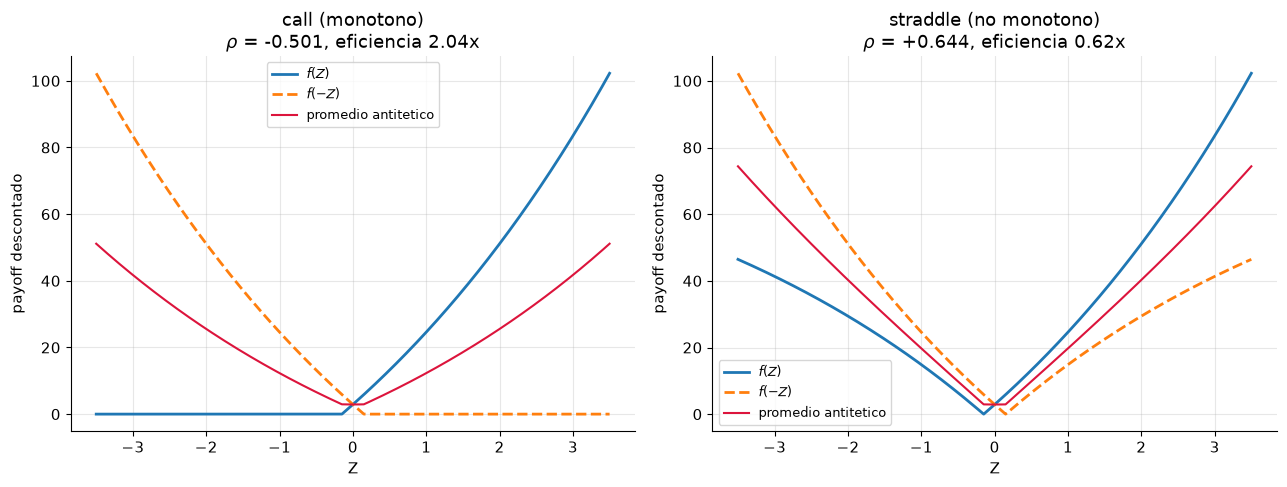

In [2]:
n_ant = 200_000
Z_plain = rng.standard_normal(n_ant)
Z_half = rng.standard_normal(n_ant // 2)

payoffs = {
    "call (monotono)": lambda S: np.maximum(S - K, 0.0),
    "straddle (no monotono)": lambda S: np.abs(S - K),
}

print(f"{'payoff':>24} | {'Var crudo':>11} | {'Var por par':>11} | {'rho':>7} | {'efic. medida':>12} | "
      f"{'1/(1+rho)':>10}")
print("-" * 92)
ant_results = {}
for name, f in payoffs.items():
    # muestra independiente: el numero operativo (lo que se gana en la practica, con su ruido)
    v_plain = (disc * f(S_T_of(Z_plain))).var(ddof=1)
    # misma muestra para las dos patas: aqui la identidad teorica es algebraica, no estadistica
    leg_up, leg_dn = disc * f(S_T_of(Z_half)), disc * f(S_T_of(-Z_half))
    pair = 0.5 * (leg_up + leg_dn)
    v_pair = pair.var(ddof=1)
    v_pooled = np.concatenate([leg_up, leg_dn]).var(ddof=1)  # estima Var f(Z) con las MISMAS normales
    rho = np.corrcoef(leg_up, leg_dn)[0, 1]
    efficiency = v_plain / (2.0 * v_pair)            # por evaluacion del payoff, no por par
    efficiency_id = v_pooled / (2.0 * v_pair)        # la misma razon, sin ruido entre muestras
    ant_results[name] = (v_plain, v_pair, rho, efficiency, pair.mean(), efficiency_id)
    print(f"{name:>24} | {v_plain:>11.4f} | {v_pair:>11.4f} | {rho:>+7.3f} | {efficiency:>12.3f} | "
          f"{1/(1+rho):>10.3f}")

print("\nLa eficiencia medida usa una muestra independiente para Var(crudo), asi que difiere de")
print("1/(1+rho) por ruido muestral (~1-2% con estos payoffs de cola pesada). Calculada sobre las")
print("MISMAS normales, la identidad se cumple como lo que es, una igualdad algebraica:")
for name, vals in ant_results.items():
    print(f"  {name:>24}: Var_pooled/(2 Var_par) = {vals[5]:.6f}  vs  1/(1+rho) = {1/(1+vals[2]):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, f) in zip(axes, payoffs.items()):
    z_grid = np.linspace(-3.5, 3.5, 400)
    ax.plot(z_grid, disc * f(S_T_of(z_grid)), lw=2, label="$f(Z)$")
    ax.plot(z_grid, disc * f(S_T_of(-z_grid)), lw=2, ls="--", label="$f(-Z)$")
    ax.plot(z_grid, 0.5 * (disc * f(S_T_of(z_grid)) + disc * f(S_T_of(-z_grid))), color="crimson",
            lw=1.5, label="promedio antitetico")
    ax.set_xlabel("Z"); ax.set_ylabel("payoff descontado")
    ax.set_title(f"{name}\n" + r"$\rho$ = " + f"{ant_results[name][2]:+.3f}, eficiencia {ant_results[name][3]:.2f}x")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. Control variates

Supongamos que junto al payoff $Y$ que no sabemos valuar hay otro $X$, correlacionado con él, **cuya esperanza $\mu_X$ conocemos exactamente**. Entonces para cualquier $c$,
$$
\hat V_c = \bar Y - c\,(\bar X - \mu_X)
$$
es insesgado (el segundo término tiene media cero) y su varianza es
$$
\text{Var}(\hat V_c) = \frac1n\Big(\sigma_Y^2 - 2c\,\text{Cov}(X,Y) + c^2\sigma_X^2\Big),
$$
una parábola en $c$ cuyo mínimo está en
$$
c^* = \frac{\text{Cov}(X,Y)}{\sigma_X^2}, \qquad\text{con}\qquad \text{Var}(\hat V_{c^*}) = \frac{\sigma_Y^2}{n}\big(1-\rho^2\big).
$$
La lectura es contundente: **la reducción depende sólo de la correlación**, y de nada más. Con $\rho=0.9$ se elimina el $81\%$ de la varianza; con $\rho=0.999$, el $99.8\%$. Buscar un buen control es buscar correlación, no parecido conceptual.

Dos precauciones: (i) estimar $c^*$ con la misma muestra introduce un sesgo $O(1/n)$ — despreciable frente al error $O(n^{-1/2})$, pero real; el remedio purista es estimar $c^*$ en una muestra piloto independiente; (ii) $\mu_X$ tiene que ser **exacto**, no aproximado: cualquier error en $\mu_X$ entra directo y sin descuento en el precio final.

**El caso que 3.3 dejó pendiente.** La asiática aritmética no tiene fórmula cerrada, pero la geométrica sí — y en 3.3 §6.1b derivamos la del promedio **discreto**, que es exacta para las mismas fechas que simula el Monte Carlo. Ahí medimos $\rho=0.9996$ entre los dos payoffs. Aquí cobramos esa correlación: con $1-\rho^2\approx8\times10^{-4}$, la reducción de varianza debería ser de tres órdenes de magnitud. Nótese que usar la fórmula **continua** como $\mu_X$ sería exactamente el error contra el que advierte 3.3: introduciría el sesgo de promediado ($\approx0.019$) directo en el precio de la aritmética.

E[geometrica discreta] analitico = 5.565509   (la continua daria 5.546819: sesgo de promediado)
correlacion(X,Y) = 0.999630   ->   1 - rho^2 = 7.390e-04
c* estimado = 1.034905   (teoria: rho*sigma_Y/sigma_X = 1.034905)

     estimador |     precio |        SE |  Var relativa
--------------------------------------------------------
      MC crudo |   5.816693 |  0.025427 |       1.00000
   control var |   5.780629 |  0.000691 |       0.00074
reduccion de varianza: 1353x  (mismo n, mismo costo por trayectoria)


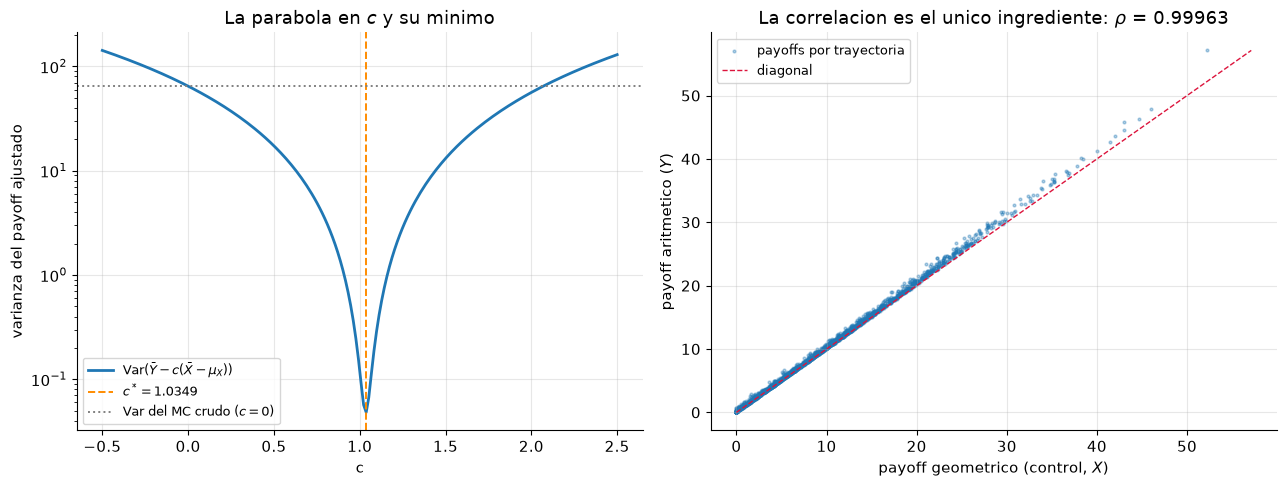

In [3]:
m_avg = 252
n_cv = 100_000


def geometric_asian_call_discrete(S0, K, r, q, sigma, T, m):
    '''Exact closed form for the discretely-monitored geometric Asian call (derived in 3.3 §6.1b).'''
    nu = r - q - 0.5 * sigma**2
    dt = T / m
    mean_log = np.log(S0) + nu * dt * (m + 1) / 2.0
    var_log = sigma**2 * dt * (m + 1) * (2 * m + 1) / (6.0 * m)
    s = np.sqrt(var_log)
    F = np.exp(mean_log + 0.5 * var_log)
    d1 = (np.log(F / K) + 0.5 * s**2) / s
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d1 - s))


mu_X = geometric_asian_call_discrete(S0, K, r, q, sigma, T, m_avg)

dt = T / m_avg
Z_paths = rng.standard_normal((n_cv, m_avg))
log_paths = np.log(S0) + np.cumsum((r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_paths, axis=1)
A = np.exp(log_paths).mean(axis=1)          # promedio aritmetico
G = np.exp(log_paths.mean(axis=1))          # promedio geometrico
Y = disc * np.maximum(A - K, 0.0)           # el que queremos
X = disc * np.maximum(G - K, 0.0)           # el control

cov = np.cov(X, Y, ddof=1)
c_star = cov[0, 1] / cov[0, 0]
rho_XY = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
Y_cv = Y - c_star * (X - mu_X)

se_plain = Y.std(ddof=1) / np.sqrt(n_cv)
se_cv = Y_cv.std(ddof=1) / np.sqrt(n_cv)
print(f"E[geometrica discreta] analitico = {mu_X:.6f}   (la continua daria {5.5468186338:.6f}: sesgo de promediado)")
print(f"correlacion(X,Y) = {rho_XY:.6f}   ->   1 - rho^2 = {1-rho_XY**2:.3e}")
print(f"c* estimado = {c_star:.6f}   (teoria: rho*sigma_Y/sigma_X = "
      f"{rho_XY*np.sqrt(cov[1,1]/cov[0,0]):.6f})")
print(f"\n{'estimador':>14} | {'precio':>10} | {'SE':>9} | {'Var relativa':>13}")
print("-" * 56)
print(f"{'MC crudo':>14} | {Y.mean():>10.6f} | {se_plain:>9.6f} | {1.0:>13.5f}")
print(f"{'control var':>14} | {Y_cv.mean():>10.6f} | {se_cv:>9.6f} | "
      f"{Y_cv.var(ddof=1)/Y.var(ddof=1):>13.5f}")
print(f"reduccion de varianza: {Y.var(ddof=1)/Y_cv.var(ddof=1):.0f}x  "
      f"(mismo n, mismo costo por trayectoria)")

c_grid = np.linspace(-0.5, 2.5, 200)
var_of_c = np.array([(Y - c * (X - mu_X)).var(ddof=1) for c in c_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(c_grid, var_of_c, lw=2, label="Var$(\\bar Y - c(\\bar X - \\mu_X))$")
ax.axvline(c_star, color="darkorange", ls="--", label=f"$c^* = {c_star:.4f}$")
ax.axhline(Y.var(ddof=1), color="gray", ls=":", label="Var del MC crudo ($c=0$)")
ax.set_yscale("log")
ax.set_xlabel("c"); ax.set_ylabel("varianza del payoff ajustado")
ax.set_title("La parabola en $c$ y su minimo")
ax.legend(fontsize=9)

ax = axes[1]
idx = rng.choice(n_cv, 4000, replace=False)
ax.scatter(X[idx], Y[idx], s=4, alpha=0.35, label="payoffs por trayectoria")
lim = [0, max(X[idx].max(), Y[idx].max())]
ax.plot(lim, lim, color="crimson", lw=1, ls="--", label="diagonal")
ax.set_xlabel("payoff geometrico (control, $X$)"); ax.set_ylabel("payoff aritmetico ($Y$)")
ax.set_title(f"La correlacion es el unico ingrediente: $\\rho$ = {rho_XY:.5f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Muestreo estratificado

En vez de sortear $n$ normales y aceptar que por azar caigan demasiadas en una región, **forzamos** la proporción correcta: partimos $(0,1)$ en $k$ estratos iguales, ponemos $n/k$ puntos en cada uno y los mapeamos con $\Phi^{-1}$:
$$
U_{ij} = \frac{i-1+\tilde U_{ij}}{k}, \qquad Z_{ij} = \Phi^{-1}(U_{ij}), \qquad i=1..k,\ j=1..n/k .
$$
El estimador $\hat V_{\text{str}} = \frac1k\sum_i\bar Y_i$ es insesgado y su varianza, **por independencia entre estratos**, es
$$
\text{Var}(\hat V_{\text{str}}) = \frac{1}{k^2}\sum_{i=1}^k\frac{\sigma_i^2}{n/k} = \frac{1}{n}\cdot\frac1k\sum_i\sigma_i^2 = \frac{\overline{\sigma^2_{\text{dentro}}}}{n},
$$
frente a $\sigma_Y^2/n$ del crudo. La descomposición de la varianza total $\sigma_Y^2 = \overline{\sigma^2_{\text{dentro}}} + \sigma^2_{\text{entre}}$ dice exactamente qué se ganó: **la estratificación elimina la varianza entre estratos, completa**. Cuanto más de la variabilidad del payoff explique la posición de $Z$ dentro de su estrato, más queda; cuanto más la explique el estrato mismo, más se elimina.

De ahí la predicción: para un payoff **escalonado** como el digital, casi toda la varianza es "entre estratos" (dentro de un estrato el payoff es constante salvo en el estrato que contiene a $K$), así que la ganancia debe ser espectacular y luego **saturarse** — con $k$ grande sólo sobrevive la contribución del único estrato donde el payoff salta. Para el call, que varía suavemente dentro de cada estrato, la ganancia crece más parejo con $k$.

Nótese que aquí sí tenemos fórmula para la varianza del estimador. Abajo la cruzamos contra el estimador por réplicas — si las dos coinciden, ambas mediciones son creíbles; es el control que en LHS (§4) no tendremos.


call: MC crudo = 10.464121, Var(estimador) = 1.078e-03  [exacto = 10.450584]
       k |   estimado |  Var(estimador) |  reduccion |  |err|/SE
      10 |  10.459198 |       8.418e-05 |      12.8x |      0.94
     100 |  10.450793 |       6.895e-06 |     156.3x |      0.08
    1000 |  10.449082 |       4.501e-07 |    2395.0x |      2.24

digital: MC crudo = 0.531067, Var(estimador) = 1.116e-06  [exacto = 0.532325]
       k |   estimado |  Var(estimador) |  reduccion |  |err|/SE
      10 |   0.532755 |       1.085e-07 |      10.3x |      1.31
     100 |   0.532265 |       1.925e-09 |     579.7x |      1.36
    1000 |   0.532294 |       1.104e-09 |    1010.7x |      0.94



Control cruzado (call, k=100, n=20,000):
  Var por la formula analitica = 6.523e-05
  Var por 200 replicas     = 6.167e-05   (razon 1.06; el estimador por replicas tiene por si solo 10.0% de error relativo)


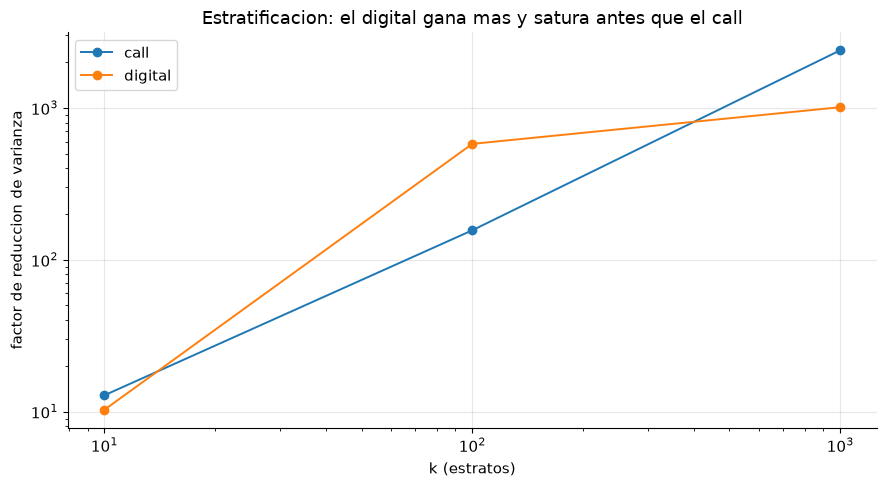

In [4]:
def stratified_estimate(k, n, payoff_fn, rng):
    '''Stratified sampling on the terminal normal. Returns (estimate, variance of the estimate).'''
    per = n // k
    lows = np.arange(k)[:, None]
    U = (lows + rng.random((k, per))) / k
    Y = disc * payoff_fn(S_T_of(norm.ppf(U)))
    within = Y.var(axis=1, ddof=1)
    return Y.mean(axis=1).mean(), within.mean() / n   # Var = mean(sigma_i^2)/n


n_str = 200_000
targets = {
    "call": (lambda S: np.maximum(S - K, 0.0), bs_call),
    "digital": (lambda S: (S > K).astype(float), cash_or_nothing),
}

strat_results = {}
for name, (f, ref) in targets.items():
    Y_plain = disc * f(S_T_of(rng.standard_normal(n_str)))
    var_plain = Y_plain.var(ddof=1) / n_str
    print(f"\n{name}: MC crudo = {Y_plain.mean():.6f}, Var(estimador) = {var_plain:.3e}  [exacto = {ref:.6f}]")
    print(f"  {'k':>6} | {'estimado':>10} | {'Var(estimador)':>15} | {'reduccion':>10} | {'|err|/SE':>9}")
    rows = []
    for k in (10, 100, 1000):
        est, var_est = stratified_estimate(k, n_str, f, rng)
        rows.append((k, est, var_est))
        print(f"  {k:>6} | {est:>10.6f} | {var_est:>15.3e} | {var_plain/var_est:>9.1f}x | "
              f"{abs(est-ref)/np.sqrt(var_est):>9.2f}")
    strat_results[name] = (var_plain, rows)

# Control cruzado: la formula analitica vs la varianza medida por replicas
R_check, n_check, k_check = 200, 20_000, 100   # R grande: el propio control tiene error sqrt(2/(R-1))
means = [stratified_estimate(k_check, n_check, targets["call"][0], rng)[0] for _ in range(R_check)]
var_replicas = np.var(means, ddof=1)
_, var_formula = stratified_estimate(k_check, n_check, targets["call"][0], rng)
print(f"\nControl cruzado (call, k={k_check}, n={n_check:,}):")
print(f"  Var por la formula analitica = {var_formula:.3e}")
print(f"  Var por {R_check} replicas     = {var_replicas:.3e}   (razon {var_formula/var_replicas:.2f}; "
      f"el estimador por replicas tiene por si solo {np.sqrt(2/(R_check-1)):.1%} de error relativo)")

fig, ax = plt.subplots(figsize=(9, 5))
for name, (var_plain, rows) in strat_results.items():
    ks = [row[0] for row in rows]
    reductions = [var_plain / row[2] for row in rows]
    ax.plot(ks, reductions, "o-", label=f"{name}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("k (estratos)"); ax.set_ylabel("factor de reduccion de varianza")
ax.set_title("Estratificacion: el digital gana mas y satura antes que el call")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Latin Hypercube Sampling — y cómo *no* medirlo

En dimensión $d$, estratificar el producto cartesiano exigiría $k^d$ estratos: imposible. **LHS** hace lo que sí escala: estratifica **cada coordenada por separado** en $n$ niveles y luego empareja los niveles al azar con una permutación independiente por dimensión. El resultado garantiza marginales perfectamente estratificadas — y **nada** sobre las interacciones entre coordenadas.

La teoría (Stein 1987) precisa esa intuición: descomponiendo $f(Z_1,\dots,Z_d)$ en su ANOVA
$$
f = \mu + \sum_i f_i(Z_i) + \sum_{i<j} f_{ij}(Z_i,Z_j) + \cdots,
$$
LHS elimina asintóticamente la varianza de los **efectos principales** $\sum_if_i$ y deja intacta la de las interacciones. De ahí la predicción verificable: LHS es espectacular cuando el payoff es esencialmente aditivo (en particular en $d=1$, donde LHS *es* estratificación con $n$ estratos) y va perdiendo fuerza conforme la dimensión reparte varianza hacia las interacciones.

**Cómo medirlo — la trampa.** Las muestras LHS **no son independientes**: la varianza muestral de los payoffs no estima la varianza del promedio. Si uno calcula `Y.var()/n` como con Monte Carlo crudo obtiene la varianza *marginal* del payoff, que LHS no cambia, y concluye alegremente que LHS "no sirve" — el resultado exacto que produce esa medición y que es falso. La medición correcta, y la única que existe para LHS sin teoría adicional, es **repetir el diseño completo $R$ veces y medir la dispersión de los $R$ promedios**. Eso es lo que hacemos aquí.

Varianza del ESTIMADOR medida con R=40 replicas de n=20,000 (unica medicion valida para LHS)
              caso |   media MC |  media LHS |     Var MC |    Var LHS |  reduccion
------------------------------------------------------------------------------------


        call (d=1) |  10.473642 |  10.450533 |  1.247e-02 |  2.218e-07 |   56231.6x


    asiatica (d=4) |   6.949828 |   6.945896 |  3.429e-03 |  6.194e-04 |       5.5x


   asiatica (d=16) |   6.073688 |   6.058076 |  2.560e-03 |  6.578e-04 |       3.9x

Para el call (d=1), la medicion ingenua 'Y.var()/n' daria 1.083e-02,
cuando la varianza real del estimador LHS es 2.218e-07 -- un factor 48,841
de diferencia. La varianza muestral no ve la estratificacion porque las muestras no son iid.


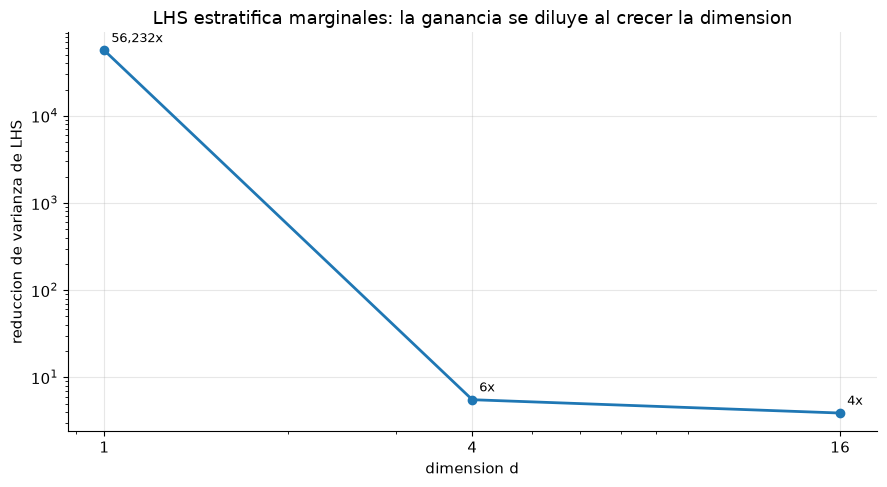

In [5]:
def asian_payoff(Z):
    '''Discretely-monitored arithmetic Asian call, one monitoring date per dimension of Z.'''
    d = Z.shape[1]
    dt_d = T / d
    log_path = np.log(S0) + np.cumsum((r - q - 0.5 * sigma**2) * dt_d + sigma * np.sqrt(dt_d) * Z, axis=1)
    return disc * np.maximum(np.exp(log_path).mean(axis=1) - K, 0.0)


def call_payoff_1d(Z):
    return disc * np.maximum(S_T_of(Z[:, 0]) - K, 0.0)


R_lhs, n_lhs = 40, 20_000
cases = [("call (d=1)", call_payoff_1d, 1), ("asiatica (d=4)", asian_payoff, 4),
         ("asiatica (d=16)", asian_payoff, 16)]

print(f"Varianza del ESTIMADOR medida con R={R_lhs} replicas de n={n_lhs:,} (unica medicion valida para LHS)")
print(f"{'caso':>18} | {'media MC':>10} | {'media LHS':>10} | {'Var MC':>10} | {'Var LHS':>10} | {'reduccion':>10}")
print("-" * 84)
lhs_reductions = {}
for name, f, d in cases:
    means_mc = np.array([f(rng.standard_normal((n_lhs, d))).mean() for _ in range(R_lhs)])
    means_lhs = np.array([f(norm.ppf(qmc.LatinHypercube(d=d, seed=1000 + i).random(n_lhs))).mean()
                          for i in range(R_lhs)])
    v_mc, v_lhs = means_mc.var(ddof=1), means_lhs.var(ddof=1)
    lhs_reductions[name] = (v_mc / v_lhs, means_mc.mean(), means_lhs.mean(), v_mc, v_lhs)
    print(f"{name:>18} | {means_mc.mean():>10.6f} | {means_lhs.mean():>10.6f} | {v_mc:>10.3e} | "
          f"{v_lhs:>10.3e} | {v_mc/v_lhs:>9.1f}x")

# La medicion INCORRECTA, para dejar constancia de lo que produce
Z_lhs_1d = norm.ppf(qmc.LatinHypercube(d=1, seed=1).random(n_lhs))
naive_var = call_payoff_1d(Z_lhs_1d).var(ddof=1) / n_lhs
correct_var = lhs_reductions["call (d=1)"][4]
print(f"\nPara el call (d=1), la medicion ingenua 'Y.var()/n' daria {naive_var:.3e},")
print(f"cuando la varianza real del estimador LHS es {correct_var:.3e} -- un factor {naive_var/correct_var:,.0f}")
print("de diferencia. La varianza muestral no ve la estratificacion porque las muestras no son iid.")

fig, ax = plt.subplots(figsize=(9, 5))
dims = [1, 4, 16]
reds = [lhs_reductions[name][0] for name, _, _ in cases]
ax.plot(dims, reds, "o-", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(dims); ax.set_xticklabels([str(d) for d in dims])
ax.set_xlabel("dimension d"); ax.set_ylabel("reduccion de varianza de LHS")
ax.set_title("LHS estratifica marginales: la ganancia se diluye al crecer la dimension")
for d, red in zip(dims, reds):
    ax.annotate(f"{red:,.0f}x", xy=(d, red), xytext=(5, 6), textcoords="offset points", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Validación

Cada técnica se contrasta contra la referencia exacta que le corresponde y contra la predicción teórica de su propio mecanismo:

1. **Antitéticas**: el precio del call dentro de 3 SE de Black-Scholes; eficiencia $>1.5$ para el call y $<1$ para el straddle (los dos signos, porque la afirmación teórica es un "si y sólo si"). La identidad $\text{eficiencia}=1/(1+\rho)$ se verifica a `rtol` $10^{-3}$ **calculada sobre la misma muestra** — ahí es una igualdad algebraica; contra una muestra independiente sólo se puede exigir `rtol` $0.05$, porque dos estimaciones de varianza de un payoff de cola pesada difieren en un par de puntos porcentuales por puro ruido. Verificar la fórmula contra muestras distintas mediría el ruido, no la fórmula.
2. **Control variates**: `c*` estimado igual a $\rho\,\sigma_Y/\sigma_X$ a `rtol` $10^{-12}$ (es la misma cantidad reescrita, así que es un test de identidad algebraica); reducción de varianza $>100\times$; el estimador con control y el crudo compatibles entre sí dentro de 3 SE combinados — la asiática aritmética no tiene fórmula cerrada, así que ésa es la única comparación honesta disponible.
3. **Estratificado**: call y digital dentro de 3 SE (con la varianza *del estimador estratificado*, no la del crudo) para todo $k$; reducción $>100\times$ en el digital con $k=100$; y la fórmula analítica de la varianza consistente con la medición por réplicas dentro de $[0.75,1.35]$ (con $R=200$ réplicas el propio estimador por réplicas tiene $\approx10\%$ de error relativo, así que ese rango es $\approx3$ desviaciones: exigir más sería exigirle precisión al control, no al método).
4. **LHS**: reducción $>1000\times$ en $d=1$ (donde LHS es estratificación pura) y $>2\times$ en $d=4$ y $d=16$; medias dentro de 3 SE de la referencia donde existe.

In [6]:
# 1. Antiteticas
call_ant_mean = ant_results["call (monotono)"][4]
se_ant = np.sqrt(ant_results["call (monotono)"][1] / (n_ant // 2))
z_ant = abs(call_ant_mean - bs_call) / se_ant
print(f"call antitetico = {call_ant_mean:.6f} vs BS: |diff|/SE = {z_ant:.3f} (<=3? {z_ant <= 3.0})")
assert z_ant <= 3.0
for name, (_, _, rho, eff, _, eff_id) in ant_results.items():
    print(f"  {name:>24}: rho={rho:+.3f} | identidad {eff_id:.6f} vs 1/(1+rho)={1/(1+rho):.6f} | "
          f"eficiencia operativa {eff:.3f}")
    np.testing.assert_allclose(eff_id, 1.0 / (1.0 + rho), rtol=1e-3)   # misma muestra: identidad
    np.testing.assert_allclose(eff, 1.0 / (1.0 + rho), rtol=0.05)      # muestras distintas: ruido
assert ant_results["call (monotono)"][3] > 1.5
assert ant_results["straddle (no monotono)"][3] < 1.0

# 2. Control variates
np.testing.assert_allclose(c_star, rho_XY * np.sqrt(cov[1, 1] / cov[0, 0]), rtol=1e-12)
var_ratio_cv = Y.var(ddof=1) / Y_cv.var(ddof=1)
print(f"control variate: reduccion = {var_ratio_cv:.0f}x (>100? {var_ratio_cv > 100})")
assert var_ratio_cv > 100.0
z_cv = abs(Y_cv.mean() - Y.mean()) / np.sqrt(se_cv**2 + se_plain**2)
print(f"  estimador con control vs MC crudo: |diff|/SE_comb = {z_cv:.3f} (<=3? {z_cv <= 3.0})")
assert z_cv <= 3.0

# 3. Estratificado
for name, (var_plain, rows) in strat_results.items():
    ref = targets[name][1]
    for k, est, var_est in rows:
        z = abs(est - ref) / np.sqrt(var_est)
        assert z <= 3.0, f"{name} k={k}: {z:.2f} SE del valor exacto"
    print(f"  {name}: los 3 valores de k dentro de 3 SE del exacto")
red_digital_100 = strat_results["digital"][0] / strat_results["digital"][1][1][2]
print(f"digital k=100: reduccion = {red_digital_100:.0f}x (>100? {red_digital_100 > 100})")
assert red_digital_100 > 100.0
ratio_check = var_formula / var_replicas
print(f"formula analitica vs replicas: razon = {ratio_check:.3f} (en [0.75,1.35]? {0.75 <= ratio_check <= 1.35})")
assert 0.75 <= ratio_check <= 1.35

# 4. LHS
for name, (red, m_mc, m_lhs, _, v_lhs) in lhs_reductions.items():
    print(f"  {name}: reduccion {red:,.1f}x")
assert lhs_reductions["call (d=1)"][0] > 1000.0
assert lhs_reductions["asiatica (d=4)"][0] > 2.0
assert lhs_reductions["asiatica (d=16)"][0] > 2.0
z_lhs_call = abs(lhs_reductions["call (d=1)"][2] - bs_call) / np.sqrt(lhs_reductions["call (d=1)"][4])
print(f"call LHS (d=1) vs BS: |diff|/SE = {z_lhs_call:.3f} (<=3? {z_lhs_call <= 3.0})")
assert z_lhs_call <= 3.0

print()
print("Validacion completa: 4/4 tecnicas dentro de tolerancia.")

call antitetico = 10.414967 vs BS: |diff|/SE = 1.537 (<=3? True)
           call (monotono): rho=-0.501 | identidad 2.004259 vs 1/(1+rho)=2.004328 | eficiencia operativa 2.043
    straddle (no monotono): rho=+0.644 | identidad 0.608092 vs 1/(1+rho)=0.608088 | eficiencia operativa 0.621
control variate: reduccion = 1353x (>100? True)
  estimador con control vs MC crudo: |diff|/SE_comb = 1.418 (<=3? True)
  call: los 3 valores de k dentro de 3 SE del exacto
  digital: los 3 valores de k dentro de 3 SE del exacto
digital k=100: reduccion = 580x (>100? True)
formula analitica vs replicas: razon = 1.058 (en [0.75,1.35]? True)
  call (d=1): reduccion 56,231.6x
  asiatica (d=4): reduccion 5.5x
  asiatica (d=16): reduccion 3.9x
call LHS (d=1) vs BS: |diff|/SE = 0.108 (<=3? True)

Validacion completa: 4/4 tecnicas dentro de tolerancia.


## Referencias

- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*, Springer, cap. 4 (las cuatro técnicas, con las demostraciones completas).
- Boyle, P., Broadie, M. & Glasserman, P. (1997). *Monte Carlo Methods for Security Pricing*. Journal of Economic Dynamics and Control, 21(8-9), 1267-1321.
- Kemna, A.G.Z. & Vorst, A.C.F. (1990). *A Pricing Method for Options Based on Average Asset Values*. Journal of Banking and Finance, 14(1), 113-129. (el control geométrico para la asiática)
- McKay, M.D., Beckman, R.J. & Conover, W.J. (1979). *A Comparison of Three Methods for Selecting Values of Input Variables*. Technometrics, 21(2), 239-245. (LHS original)
- Stein, M. (1987). *Large Sample Properties of Simulations Using Latin Hypercube Sampling*. Technometrics, 29(2), 143-151. (por qué LHS elimina los efectos principales del ANOVA)
- Owen, A.B. (2013). *Monte Carlo Theory, Methods and Examples*, caps. 8-10 (tratamiento moderno y unificado).